<a href="https://colab.research.google.com/github/Ayushman-7846/MRS/blob/main/MRS_nlp_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nltk textblob scikit-learn sentence-transformers

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import numpy as np
import pandas as pd
import ast
import re

from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords

from sklearn.metrics.pairwise import cosine_similarity
from textblob import TextBlob

from sentence_transformers import SentenceTransformer

In [ ]:
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

In [ ]:
movies = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')

movies = movies.merge(credits, on='title')

movies = movies[['movie_id','title','overview','genres','keywords','cast','crew','vote_average','popularity']]
movies.dropna(inplace=True)
movies.reset_index(drop=True, inplace=True)

FileNotFoundError: [Errno 2] No such file or directory: 'tmdb_5000_movies.csv'

In [ ]:
def convert(text):
    return [i['name'] for i in ast.literal_eval(text)]

def convert_cast(text):
    return [i['name'] for i in ast.literal_eval(text)[:5]]

def fetch_director(text):
    for i in ast.literal_eval(text):
        if i['job'] == 'Director':
            return [i['name']]
    return []

In [ ]:
movies['genres'] = movies['genres'].apply(convert)
movies['keywords'] = movies['keywords'].apply(convert)
movies['cast'] = movies['cast'].apply(convert_cast)
movies['crew'] = movies['crew'].apply(fetch_director)

movies['overview'] = movies['overview'].apply(lambda x: x.split())

In [ ]:
def collapse(L):
    return [i.replace(" ", "") for i in L]

for col in ['genres','keywords','cast','crew']:
    movies[col] = movies[col].apply(collapse)

movies['tags'] = movies['overview'] + movies['genres'] + movies['keywords'] + movies['cast'] + movies['crew']

In [ ]:
new_df = movies[['movie_id','title','tags','vote_average','popularity']].copy()
new_df['tags'] = new_df['tags'].apply(lambda x: " ".join(x).lower())

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(new_df['tags'].tolist(), show_progress_bar=True)

similarity = cosine_similarity(embeddings)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/151 [00:00<?, ?it/s]

In [ ]:
def recommend(movie, top_n=5):
    movie = movie.lower()
    matched = new_df[new_df['title'].str.lower() == movie]

    if matched.empty:
        return "Movie not found"

    index = matched.index[0]
    distances = similarity[index]

    movie_list = sorted(list(enumerate(distances)),
                        reverse=True,
                        key=lambda x: x[1])[1:top_n+1]

    return [new_df.iloc[i[0]]['title'] for i in movie_list]

In [ ]:
def semantic_search(query, top_n=5):
    query_embedding = model.encode([query])
    sim_scores = cosine_similarity(query_embedding, embeddings).flatten()

    top_indices = sim_scores.argsort()[::-1][:top_n]

    return [new_df.iloc[i]['title'] for i in top_indices]

In [ ]:
mood_map = {
    "happy": "comedy fun friendship",
    "sad": "emotional drama",
    "thriller": "crime suspense mystery",
    "scifi": "space future technology"
}

def recommend_by_mood(mood):
    return semantic_search(mood_map.get(mood, mood))

In [ ]:
def analyze_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    return "POSITIVE" if polarity > 0 else "NEGATIVE"

In [ ]:
def smart_recommender(user_input):
    if user_input.lower() in new_df['title'].str.lower().values:
        return recommend(user_input)
    else:
        return semantic_search(user_input)

In [ ]:
recommend("Avatar")
semantic_search("dark psychological thriller")
recommend_by_mood("happy")
smart_recommender("I want a sci-fi movie")

['Gattaca', 'The 6th Day', 'Fortress', 'Invaders from Mars', "Logan's Run"]

In [ ]:
smart_recommender("I want a thriller movie")

['Deadfall', 'Grindhouse', 'Margin Call', 'Hereafter', 'The Sixth Sense']

In [ ]:
recommend_by_mood("lonely")

['How to Be Single',
 'Swept Away',
 'The Lake House',
 'From Justin to Kelly',
 '200 Cigarettes']

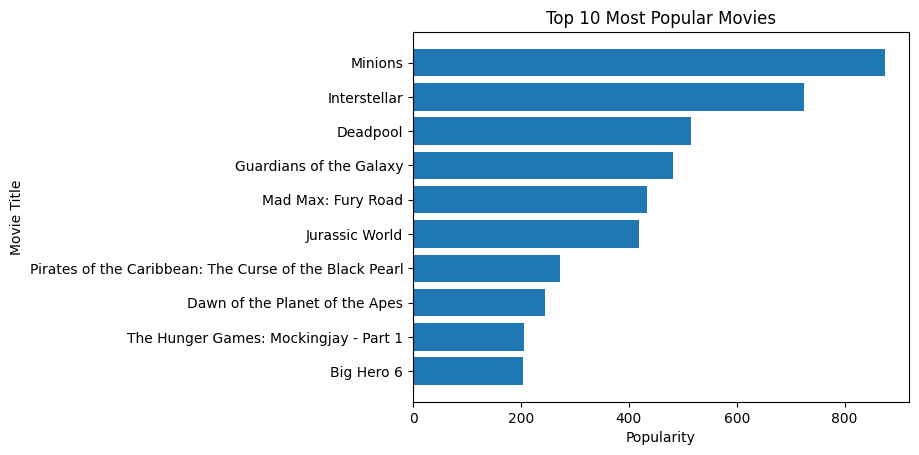

In [ ]:
import matplotlib.pyplot as plt

top_popular = new_df.sort_values(by='popularity', ascending=False).head(10)

plt.figure()
plt.barh(top_popular['title'], top_popular['popularity'])
plt.xlabel("Popularity")
plt.ylabel("Movie Title")
plt.title("Top 10 Most Popular Movies")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
plt.figure()
plt.hist(new_df['vote_average'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.title("Distribution of Movie Ratings")
plt.show()

NameError: name 'plt' is not defined

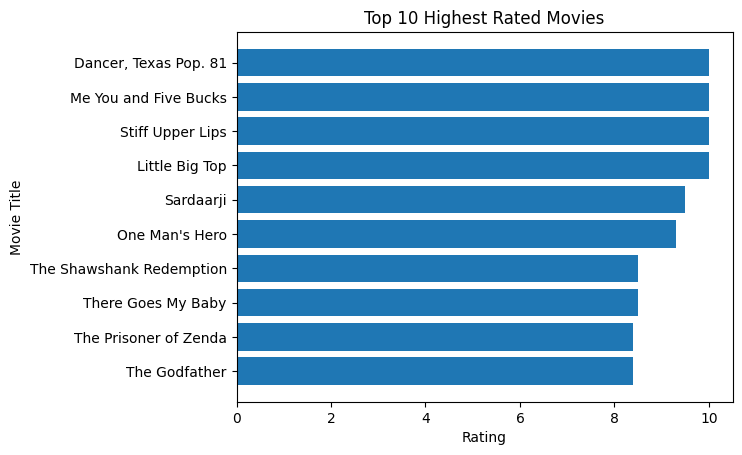

In [ ]:
top_rated = new_df.sort_values(by='vote_average', ascending=False).head(10)

plt.figure()
plt.barh(top_rated['title'], top_rated['vote_average'])
plt.xlabel("Rating")
plt.ylabel("Movie Title")
plt.title("Top 10 Highest Rated Movies")
plt.gca().invert_yaxis()
plt.show()

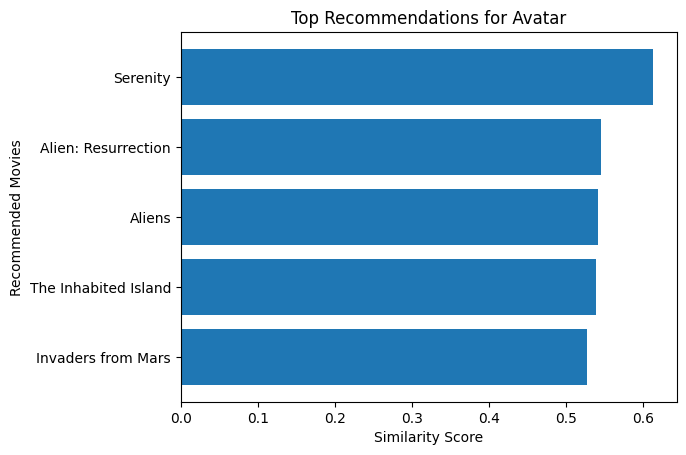

In [ ]:
movie_name = "Avatar"

matched = new_df[new_df['title'].str.lower() == movie_name.lower()]
index = matched.index[0]

distances = similarity[index]
movie_list = sorted(list(enumerate(distances)),
                    reverse=True,
                    key=lambda x: x[1])[1:6]

titles = [new_df.iloc[i[0]]['title'] for i in movie_list]
scores = [i[1] for i in movie_list]

plt.figure()
plt.barh(titles, scores)
plt.xlabel("Similarity Score")
plt.ylabel("Recommended Movies")
plt.title(f"Top Recommendations for {movie_name}")
plt.gca().invert_yaxis()
plt.show()

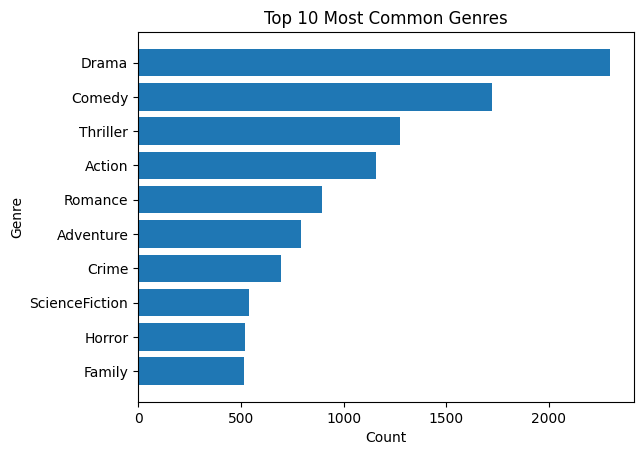

In [ ]:
from collections import Counter

all_genres = []
for row in movies['genres']:
    all_genres.extend(row)

genre_count = Counter(all_genres).most_common(10)

genres = [i[0] for i in genre_count]
counts = [i[1] for i in genre_count]

plt.figure()
plt.barh(genres, counts)
plt.xlabel("Count")
plt.ylabel("Genre")
plt.title("Top 10 Most Common Genres")
plt.gca().invert_yaxis()
plt.show()

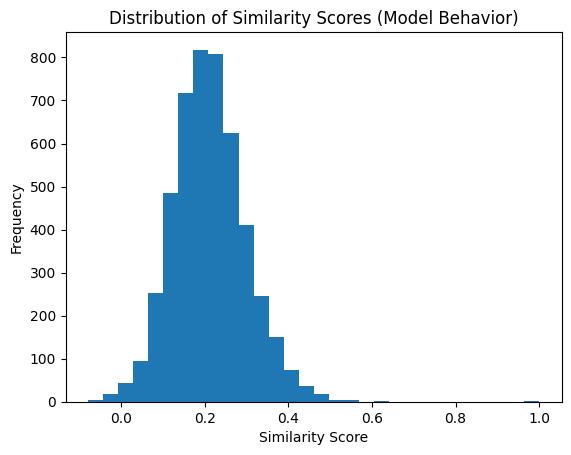

In [ ]:
import matplotlib.pyplot as plt

# Take similarity scores of one movie
sample_scores = similarity[0]

plt.figure()
plt.hist(sample_scores, bins=30)
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.title("Distribution of Similarity Scores (Model Behavior)")
plt.show()

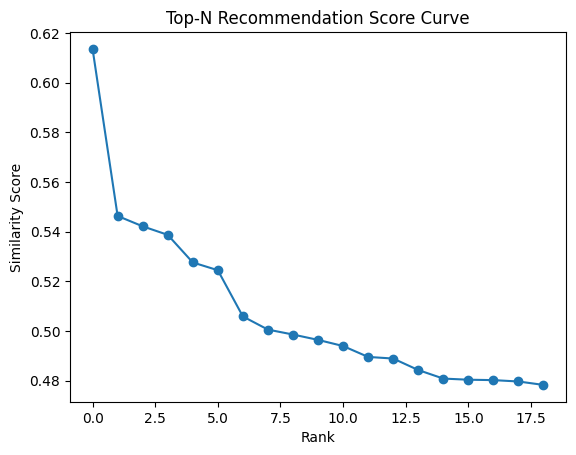

In [ ]:
movie_name = "Avatar"

matched = new_df[new_df['title'].str.lower() == movie_name.lower()]
index = matched.index[0]

distances = similarity[index]
scores = sorted(distances, reverse=True)[1:20]

plt.figure()
plt.plot(scores, marker='o')
plt.xlabel("Rank")
plt.ylabel("Similarity Score")
plt.title("Top-N Recommendation Score Curve")
plt.show()

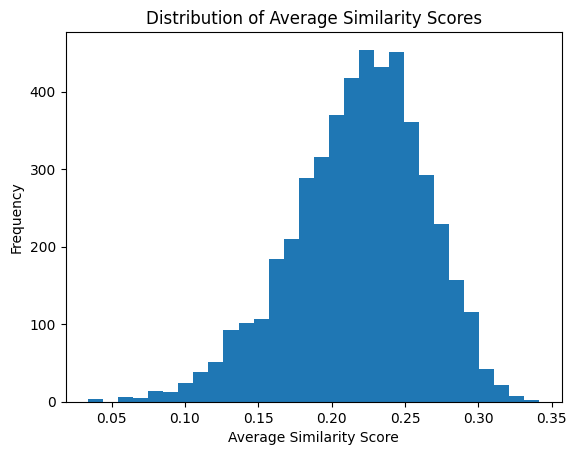

In [ ]:
avg_sim = np.mean(similarity, axis=1)

plt.figure()
plt.hist(avg_sim, bins=30)
plt.xlabel("Average Similarity Score")
plt.ylabel("Frequency")
plt.title("Distribution of Average Similarity Scores")
plt.show()

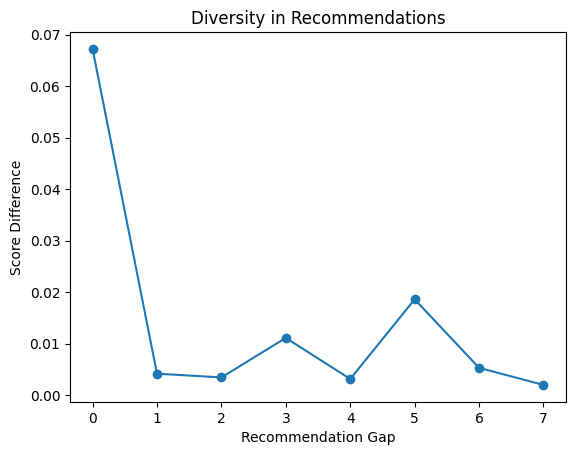

In [ ]:
movie_name = "Avatar"

matched = new_df[new_df['title'].str.lower() == movie_name.lower()]
index = matched.index[0]

distances = similarity[index]
top_scores = sorted(distances, reverse=True)[1:10]

diversity = [abs(top_scores[i] - top_scores[i+1]) for i in range(len(top_scores)-1)]

plt.figure()
plt.plot(diversity, marker='o')
plt.xlabel("Recommendation Gap")
plt.ylabel("Score Difference")
plt.title("Diversity in Recommendations")
plt.show()

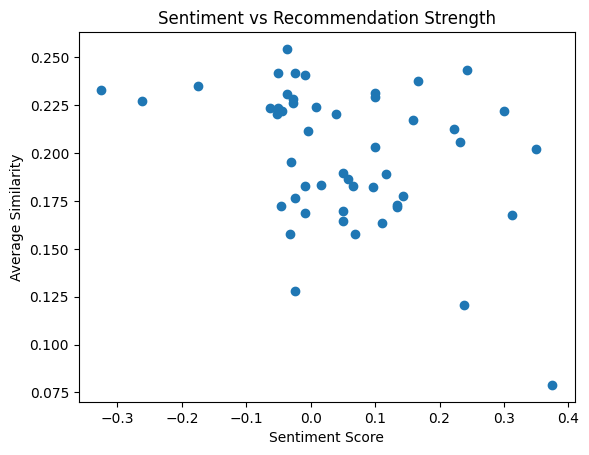

In [ ]:
movies_sample = new_df.head(50)

sentiments = []
similarities = []

for i in range(50):
    text = movies_sample.iloc[i]['tags']
    polarity = TextBlob(text).sentiment.polarity
    sentiments.append(polarity)
    similarities.append(np.mean(similarity[i]))

plt.figure()
plt.scatter(sentiments, similarities)
plt.xlabel("Sentiment Score")
plt.ylabel("Average Similarity")
plt.title("Sentiment vs Recommendation Strength")
plt.show()